<a href="https://colab.research.google.com/github/pranojit9/AI-In-Healthcare/blob/main/Coding_Assignment_2/python_script_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully

First 5 Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  wo

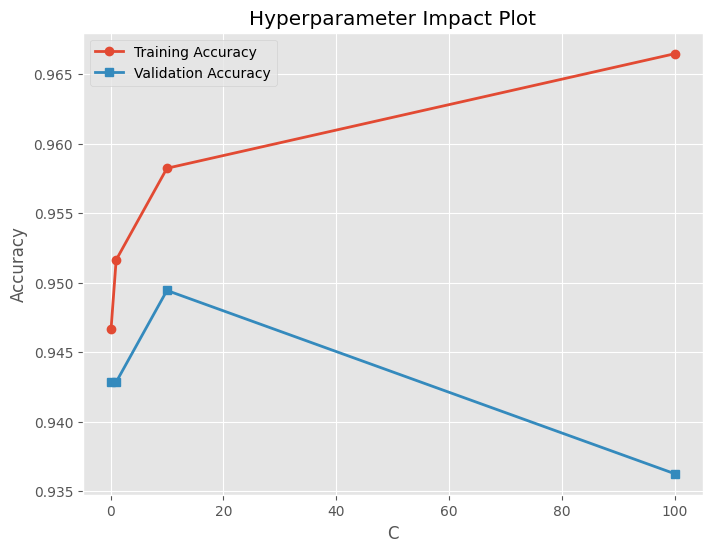

Hyperparameter Impact Plot Saved Successfully!

Generating Model Comparison Chart...


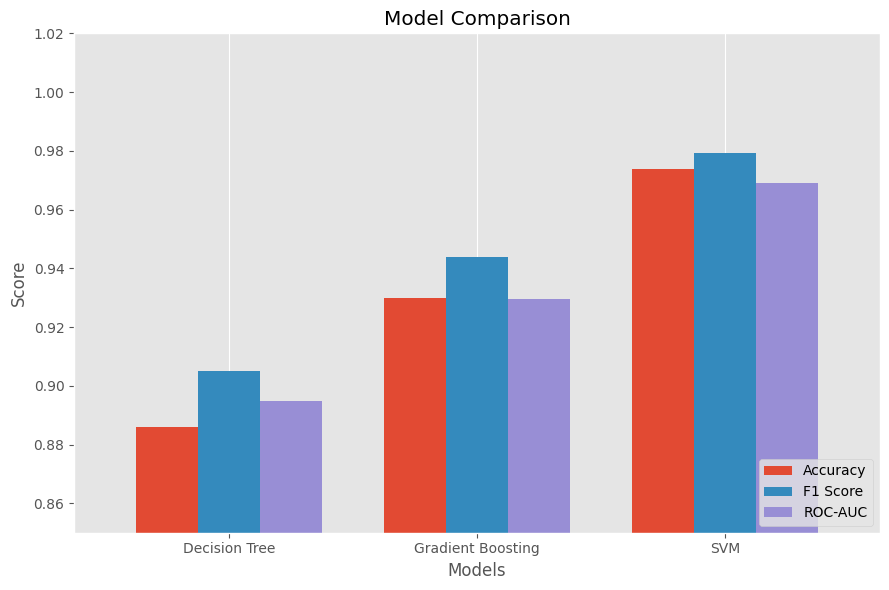

Model Comparison Chart Saved Successfully!

Generating Confusion Matrix...


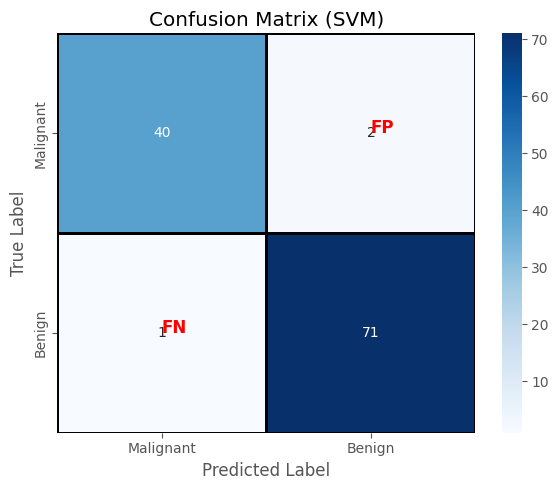

Confusion Matrix Saved Successfully!

Final Model Performance
                   Accuracy  Precision  Recall  F1 Score  ROC-AUC
Decision Tree        0.8860     0.9538  0.8611    0.9051   0.8948
Gradient Boosting    0.9298     0.9571  0.9306    0.9437   0.9296
SVM                  0.9737     0.9726  0.9861    0.9793   0.9692

Best Performing Model:
SVM

Performance Metrics:
Accuracy    : 0.9737
Precision   : 0.9726
Recall      : 0.9861
F1 Score    : 0.9793
ROC-AUC     : 0.9692

All required visualizations have been generated and saved.
Files Saved:
1. hyperparameter_impact.png
2. model_comparison.png
3. confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Phase A: Data Engineering & Feature Selection

# Import Required Libraries
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------
# Step 1: Load Dataset and Convert to DataFrame
# ----------------------------------------------------------

# Load Breast Cancer Wisconsin Dataset
cancer = load_breast_cancer()

# Create DataFrame with feature names
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add target column
df["target"] = cancer.target

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print("\nFirst 5 Rows:")
print(df.head())

# ----------------------------------------------------------
# Step 2: Dataset Information
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("Dataset Information")
print("=" * 60)

print(f"\nDataset Shape: {df.shape}")

print("\nTarget Classes:")
for i, label in enumerate(cancer.target_names):
    print(f"{i} -> {label}")

print("\nDataset Summary:")
print(df.info())

# ----------------------------------------------------------
# Step 3: Data Integrity Check
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("Missing Value Check")
print("=" * 60)

missing_values = df.isnull().sum()

if missing_values.sum() == 0:
    print("\n✅ No missing values found in the dataset.")
else:
    print("\n⚠ Missing values detected:")
    print(missing_values[missing_values > 0])

# ----------------------------------------------------------
# Step 4: Feature Engineering
# Correlation-Based Feature Selection
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("Top 5 Correlated Features")
print("=" * 60)

# Correlation with target variable
correlation = df.corr()["target"].drop("target")

# Select top 5 absolute correlations
top_features = correlation.abs().sort_values(
    ascending=False
).head(5)

print(top_features)

# ----------------------------------------------------------
# Step 5: Create Feature Subset
# ----------------------------------------------------------

selected_features = top_features.index.tolist()

print("\nSelected Features:")
for feature in selected_features:
    print("-", feature)

# Feature matrix
X = df[selected_features]

# Target variable
y = df["target"]

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

# ----------------------------------------------------------
# Step 6: Feature Scaling
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("Feature Scaling Using StandardScaler")
print("=" * 60)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=selected_features
)

print("\nScaled Features (First 5 Rows):")
print(X_scaled.head())

# ----------------------------------------------------------
# Step 7: Verify Standardization
# ----------------------------------------------------------

print("\n" + "=" * 60)
print("Scaling Verification")
print("=" * 60)

print("\nFeature Means:")
print(X_scaled.mean())

print("\nFeature Standard Deviations:")
print(X_scaled.std())

print("\n✅ Phase A Completed Successfully!")
print("Selected Features Ready For Model Training.")

# ==========================================================
# Phase B: Model Implementation & Hyperparameter Tuning
# ==========================================================

# Import Required Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ----------------------------------------------------------
# Step 1: Split Dataset into Training and Testing Sets
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("Dataset Split Completed")
print("=" * 60)
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")


# ==========================================================
# Decision Tree Classifier (Baseline Model)
# ==========================================================

print("\n" + "=" * 60)
print("Decision Tree Hyperparameter Tuning")
print("=" * 60)

dt_params = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

print("\nBest Parameters:")
print(dt_grid.best_params_)

dt_pred = best_dt.predict(X_test)

dt_metrics = {
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred),
    "Recall": recall_score(y_test, dt_pred),
    "F1 Score": f1_score(y_test, dt_pred),
    "ROC-AUC": roc_auc_score(y_test, dt_pred)
}

print("\nDecision Tree Performance")
for metric, value in dt_metrics.items():
    print(f"{metric:<12}: {value:.4f}")

print("\nClassification Report")
print(classification_report(y_test, dt_pred))


# ==========================================================
# Gradient Boosting Classifier (Advanced Ensemble)
# ==========================================================

print("\n" + "=" * 60)
print("Gradient Boosting Hyperparameter Tuning")
print("=" * 60)

gb_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_

print("\nBest Parameters:")
print(gb_grid.best_params_)

gb_pred = best_gb.predict(X_test)

gb_metrics = {
    "Accuracy": accuracy_score(y_test, gb_pred),
    "Precision": precision_score(y_test, gb_pred),
    "Recall": recall_score(y_test, gb_pred),
    "F1 Score": f1_score(y_test, gb_pred),
    "ROC-AUC": roc_auc_score(y_test, gb_pred)
}

print("\nGradient Boosting Performance")
for metric, value in gb_metrics.items():
    print(f"{metric:<12}: {value:.4f}")

print("\nClassification Report")
print(classification_report(y_test, gb_pred))


# ==========================================================
# Support Vector Machine (RBF Kernel)
# ==========================================================

print("\n" + "=" * 60)
print("SVM Hyperparameter Tuning")
print("=" * 60)

svm_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

svm_grid = GridSearchCV(
    SVC(probability=True),
    param_grid=svm_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_

print("\nBest Parameters:")
print(svm_grid.best_params_)

svm_pred = best_svm.predict(X_test)

svm_metrics = {
    "Accuracy": accuracy_score(y_test, svm_pred),
    "Precision": precision_score(y_test, svm_pred),
    "Recall": recall_score(y_test, svm_pred),
    "F1 Score": f1_score(y_test, svm_pred),
    "ROC-AUC": roc_auc_score(y_test, svm_pred)
}

print("\nSVM Performance")
for metric, value in svm_metrics.items():
    print(f"{metric:<12}: {value:.4f}")

print("\nClassification Report")
print(classification_report(y_test, svm_pred))


# ==========================================================
# Model Comparison
# ==========================================================

results = {
    "Decision Tree": dt_metrics,
    "Gradient Boosting": gb_metrics,
    "SVM": svm_metrics
}

results_df = (
    pd.DataFrame(results)
    .T
    .round(4)
)

print("\n" + "=" * 60)
print("Model Comparison")
print("=" * 60)

print(results_df)


# ==========================================================
# Best Performing Model
# ==========================================================

best_model_name = results_df["Accuracy"].idxmax()

print("\n" + "=" * 60)
print("Best Performing Model")
print("=" * 60)

print(f"Best Model : {best_model_name}")
print(f"Accuracy   : {results_df.loc[best_model_name, 'Accuracy']:.4f}")

if best_model_name == "Decision Tree":
    best_model = best_dt
    best_predictions = dt_pred

elif best_model_name == "Gradient Boosting":
    best_model = best_gb
    best_predictions = gb_pred

else:
    best_model = best_svm
    best_predictions = svm_pred

    # ==========================================================
# Phase C: Visualization & Advanced Evaluation
# ==========================================================

# Import Required Libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import validation_curve
from sklearn.metrics import confusion_matrix

# Set Plot Style
plt.style.use("ggplot")

# ==========================================================
# 1. Hyperparameter Impact Plot
# ==========================================================

print("=" * 60)
print("Generating Hyperparameter Impact Plot...")
print("=" * 60)

# Select a hyperparameter based on the best model
if best_model_name == "Decision Tree":

    param_name = "max_depth"
    param_range = [2, 3, 4, 5, 6, 8, 10]

    train_scores, validation_scores = validation_curve(
        DecisionTreeClassifier(random_state=42),
        X_train,
        y_train,
        param_name=param_name,
        param_range=param_range,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

elif best_model_name == "Gradient Boosting":

    param_name = "n_estimators"
    param_range = [50, 100, 150, 200]

    train_scores, validation_scores = validation_curve(
        GradientBoostingClassifier(random_state=42),
        X_train,
        y_train,
        param_name=param_name,
        param_range=param_range,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

else:

    param_name = "C"
    param_range = [0.1, 1, 10, 100]

    train_scores, validation_scores = validation_curve(
        SVC(kernel="rbf"),
        X_train,
        y_train,
        param_name=param_name,
        param_range=param_range,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(
    param_range,
    train_mean,
    marker='o',
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    param_range,
    validation_mean,
    marker='s',
    linewidth=2,
    label="Validation Accuracy"
)

plt.title("Hyperparameter Impact Plot")
plt.xlabel(param_name)
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("hyperparameter_impact.png", dpi=300)
plt.show()

print("Hyperparameter Impact Plot Saved Successfully!")

# ==========================================================
# 2. Model Comparison Matrix
# ==========================================================

print("\n" + "=" * 60)
print("Generating Model Comparison Chart...")
print("=" * 60)

comparison = results_df[["Accuracy", "F1 Score", "ROC-AUC"]]

ax = comparison.plot(
    kind="bar",
    figsize=(9,6),
    width=0.75
)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.85, 1.02)
plt.legend(loc="lower right")
plt.grid(axis="y")

plt.tight_layout()

plt.savefig("model_comparison.png", dpi=300)

plt.show()

print("Model Comparison Chart Saved Successfully!")

# ==========================================================
# 3. Confusion Matrix Heatmap
# ==========================================================

print("\n" + "=" * 60)
print("Generating Confusion Matrix...")
print("=" * 60)

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    linewidths=1,
    linecolor='black',
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Highlight False Positive and False Negative
plt.text(1.5, 0.5, "FP", color="red", fontsize=12, fontweight="bold")
plt.text(0.5, 1.5, "FN", color="red", fontsize=12, fontweight="bold")

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

print("Confusion Matrix Saved Successfully!")

# ==========================================================
# 4. Summary of Model Performance
# ==========================================================

print("\n" + "=" * 60)
print("Final Model Performance")
print("=" * 60)

print(results_df)

print("\nBest Performing Model:")
print(best_model_name)

print("\nPerformance Metrics:")

for metric in results_df.columns:
    print(f"{metric:<12}: {results_df.loc[best_model_name, metric]:.4f}")

print("\nAll required visualizations have been generated and saved.")

print("Files Saved:")
print("1. hyperparameter_impact.png")
print("2. model_comparison.png")
print("3. confusion_matrix.png")

from google.colab import files

files.download("hyperparameter_impact.png")
files.download("model_comparison.png")
files.download("confusion_matrix.png")